# EDA – Gaming & Academic Performance

> **Bản sửa theo góp ý.** Cấu trúc theo "Lộ trình EDA" (mục 0 → 6). Các lỗi đã sửa: kiểm tra trùng bỏ cột ID, thêm kiểm tra giá trị vô lý theo domain, đếm outlier bằng code, histogram `discrete=True` cho `age`, countplot có `order` và %, scatter có `alpha`, ẩn subplot trống, boxplot categorical tách từng hình, thêm effect size, VIF không chứa target, và dữ liệu gốc không bị ghi đè (`data` → `df` đã làm sạch).
> Kết luận viết bằng tiếng Anh; ghi chú giải thích viết bằng tiếng Việt.

# 0. Problem Definition & Setup

## 0.1. Objective & research questions

**Objective:** identify which student habits and characteristics are associated with academic grades, and prepare the data for a predictive model.

**Research questions**
1. Is the data clean and reliable enough for analysis?
2. Which habits (study, gaming, sleep, attendance) are most strongly related to grades?
3. Does the *type* of game or the student's gender matter?
4. Are some variables redundant (carrying the same information)?
5. Which features should be used to predict grades?

## 0.2. Import libraries & load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)

data = pd.read_csv('Gaming_Academic_Performance.csv')   # raw data - never modified
data.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.230,8.780,6.960,91.440,FPS,3.250,9.360,235.840,14.690,Low,86.460
1,2,19,Male,0.070,8.720,7.630,63.630,Casual,1.020,3.210,328.710,2.470,Medium,98.230
2,3,23,Female,1.730,9.560,4.400,83.260,Casual,3.460,5.560,313.610,4.730,High,90.560
3,4,20,Female,6.620,1.680,7.830,75.040,RPG,1.460,11.780,241.840,14.540,Low,32.670
4,5,22,Female,5.360,5.830,5.550,65.570,FPS,1.010,8.230,249.310,12.480,Low,58.710


# 1. Data Understanding

## 1.1. Dataset overview

In [2]:
print('Shape:', data.shape)
data.info()

Shape: (8000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   str    
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   str    
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   str    
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), str(3)
memory usage: 875.1 KB


**Conclusion:** The dataset has **8,000 rows and 14 columns**: 11 numeric and 3 text columns. All data types are correct (no numeric column was read as text). `student_id` is only an identifier and is not used in the analysis.

## 1.2. Variable dictionary

No official data dictionary was provided, so the meaning and valid ranges below are **assumptions** based on the column names.

| Column | Meaning | Unit | Type | Valid range (assumed) |
| --- | --- | --- | --- | --- |
| `age` | Student age | years | numerical (discrete) | 16–24 |
| `gender` | Gender | – | nominal | Male / Female / Other |
| `gaming_hours` | Time spent gaming | hours/day | numerical | 0–24 |
| `study_hours` | Time spent studying | hours/day | numerical | 0–24 |
| `sleep_hours` | Sleep time | hours/day | numerical | 0–24 |
| `attendance` | Class attendance | % | numerical | 0–100 |
| `gaming_genre` | Main game genre | – | nominal | FPS / Casual / RPG |
| `social_activity` | Time for social activities | hours/day | numerical | ≥ 0 |
| `device_usage` | Total screen time | hours/day | numerical | 0–24, ≥ gaming_hours |
| `reaction_time_ms` | Reaction time | milliseconds | numerical | > 0 |
| `addiction_score` | Gaming addiction score | points | numerical | ≥ 0 |
| `stress_level` | Stress level | – | ordinal | Low < Medium < High |
| `grades` | Final grade (**target**) | points | numerical | 0–100 |

## 1.3. Define target, numerical & categorical features

In [3]:
target = 'grades'
num_cols = ['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
            'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score']
cat_cols = ['gender', 'gaming_genre']          # nominal: no order
ord_cols = ['stress_level']                    # ordinal: has an order
stress_order = ['Low', 'Medium', 'High']

print('Numerical  :', num_cols)
print('Categorical:', cat_cols)
print('Ordinal    :', ord_cols)
print('Target     :', target)

Numerical  : ['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score']
Categorical: ['gender', 'gaming_genre']
Ordinal    : ['stress_level']
Target     : grades


> **Tại sao tách `ord_cols` riêng?** `stress_level` có thứ tự (Low < Medium < High) nên có thể đổi sang số 1–2–3 để tính tương quan, còn `gender` và `gaming_genre` thì không có thứ tự. Mỗi cột chỉ nằm trong một danh sách, tránh bị đếm hai lần.

## 1.4. Summary statistics

In [4]:
data[num_cols + [target]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,8000.000,19.984,2.587,16.000,18.000,20.000,22.000,24.000
gaming_hours,8000.000,4.086,2.309,0.000,2.130,4.130,6.060,8.000
study_hours,8000.000,5.461,2.576,1.000,3.240,5.460,7.660,10.000
sleep_hours,8000.000,6.493,1.443,4.000,5.240,6.505,7.730,9.000
attendance,8000.000,79.887,11.580,60.000,69.780,79.695,90.100,100.000
social_activity,8000.000,2.508,1.441,0.000,1.288,2.500,3.760,5.000
device_usage,8000.000,7.586,2.710,1.100,5.560,7.610,9.600,13.950
reaction_time_ms,8000.000,271.106,29.441,183.260,247.160,270.475,294.690,347.870
addiction_score,8000.000,9.908,5.036,-4.510,5.920,10.005,13.860,23.160
grades,8000.000,66.181,22.422,0.000,49.880,67.070,83.992,118.633


In [5]:
data[cat_cols + ord_cols].nunique()

gender          3
gaming_genre    3
stress_level    3
dtype: int64

**Conclusion:**
- For every numerical column, the mean is very close to the median, which suggests **symmetric distributions**.
- Many columns have "hard" limits (e.g. `gaming_hours` 0–8, `study_hours` 1–10, `sleep_hours` 4–9, `attendance` 60–100). This suggests the data is **synthetic** (generated), not collected from real students.
- Two values are **outside the valid range** in 1.2: `addiction_score` has a minimum of **-4.51** and `grades` has a maximum of **118.6**. They are checked in 2.4.
- Each text column has exactly 3 levels.

# 2. Data Quality & Cleaning

## 2.1. Missing values

In [6]:
missing = data.isnull().sum()
print('Columns with missing values:', (missing > 0).sum())

# Hidden missing values: empty strings or placeholder text in text columns
hidden = {col: data[col].str.strip().isin(['', '?', 'NA', 'N/A', 'null']).sum()
          for col in cat_cols + ord_cols}
hidden

Columns with missing values: 0


{'gender': np.int64(0),
 'gaming_genre': np.int64(0),
 'stress_level': np.int64(0)}

**Conclusion:** There are **no missing values**, including hidden ones (empty strings or placeholders such as "N/A"). No imputation is needed.

## 2.2. Duplicates

In [7]:
print('Duplicate rows (ignoring student_id):', data.drop(columns='student_id').duplicated().sum())
print('Duplicate student_id               :', data['student_id'].duplicated().sum())

Duplicate rows (ignoring student_id): 0
Duplicate student_id               : 0


**Conclusion:** There are **no duplicated records**, even when `student_id` is ignored, and every `student_id` is unique.

## 2.3. Data types & format

In [8]:
# Count values with more than 2 decimal places in each float column
def n_long_decimals(s):
    return (s.astype(str).str.split('.').str[1].str.len() > 2).sum()

data.select_dtypes('float').apply(n_long_decimals)

gaming_hours           0
study_hours            0
sleep_hours            0
attendance             0
social_activity        0
device_usage           0
reaction_time_ms       0
addiction_score        0
grades              1671
dtype: int64

In [9]:
long_dec = data['grades'].astype(str).str.split('.').str[1].str.len() > 2
data.groupby(long_dec.rename('grades_long_decimals'))['grades'].describe()

,count,mean,std,min,25%,50%,75%,max
grades_long_decimals,,,,,,,,
False,6329.000,63.809,22.864,0.000,47.010,63.520,82.460,100.000
True,1671.000,75.165,18.031,6.523,63.758,76.498,87.142,118.633


**Conclusion:** All float columns use 2 decimal places, **except 1,671 grades** (20.9%) with many decimals (e.g. 86.459555). This group has a higher mean (75.2 vs 63.8) and contains **every** grade above 100. These rows were probably **modified after the data was generated** (for example, a bonus or noise added after grades were capped at 100). The cause is unknown, so the rows are kept, but this is noted as a limitation.

## 2.4. Invalid values (domain rules)

In [10]:
rules = {
    'grades > 100'                         : data['grades'] > 100,
    'grades == 100 (exactly)'              : data['grades'] == 100,
    'addiction_score < 0'                  : data['addiction_score'] < 0,
    'device_usage < gaming_hours'          : data['device_usage'] < data['gaming_hours'],
    'gaming + study + sleep > 24 hours'    : data[['gaming_hours', 'study_hours', 'sleep_hours']].sum(axis=1) > 24,
}
rule_table = pd.DataFrame({'rows': {k: v.sum() for k, v in rules.items()}})
rule_table['%'] = (rule_table['rows'] / len(data) * 100).round(2)
rule_table

,rows,%
grades > 100,134,1.680
grades == 100 (exactly),439,5.490
addiction_score < 0,107,1.340
device_usage < gaming_hours,0,0.000
gaming + study + sleep > 24 hours,98,1.230


**Conclusion:**
- **134 grades (1.7%) are above 100** and **107 addiction scores (1.3%) are negative**. These values are impossible, so they are errors.
- **439 grades are exactly 100**, which shows that grades were **capped at 100** (ceiling effect).
- `device_usage` is never smaller than `gaming_hours`, which is logically consistent (gaming is part of screen time).
- **98 students (1.2%)** report more than 24 hours of gaming + study + sleep per day. This is only impossible if all three are measured per day, which is not confirmed, so these rows are **flagged but kept**.

## 2.5. Categorical consistency

In [11]:
for col in cat_cols + ord_cols:
    print(col, '->', data[col].unique(),
          '| extra spaces:', (data[col] != data[col].str.strip()).sum())

gender -> <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str | extra spaces: 0
gaming_genre -> <StringArray>
['FPS', 'Casual', 'RPG']
Length: 3, dtype: str | extra spaces: 0
stress_level -> <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str | extra spaces: 0


**Conclusion:** All text columns have clean, consistent labels: no spelling variants, no case differences and no extra spaces.

## 2.6. Outliers

In [12]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

data[num_cols + [target]].apply(iqr_outliers).rename('IQR outliers').to_frame().T

,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
IQR outliers,0,0,0,0,0,0,0,0,0,0


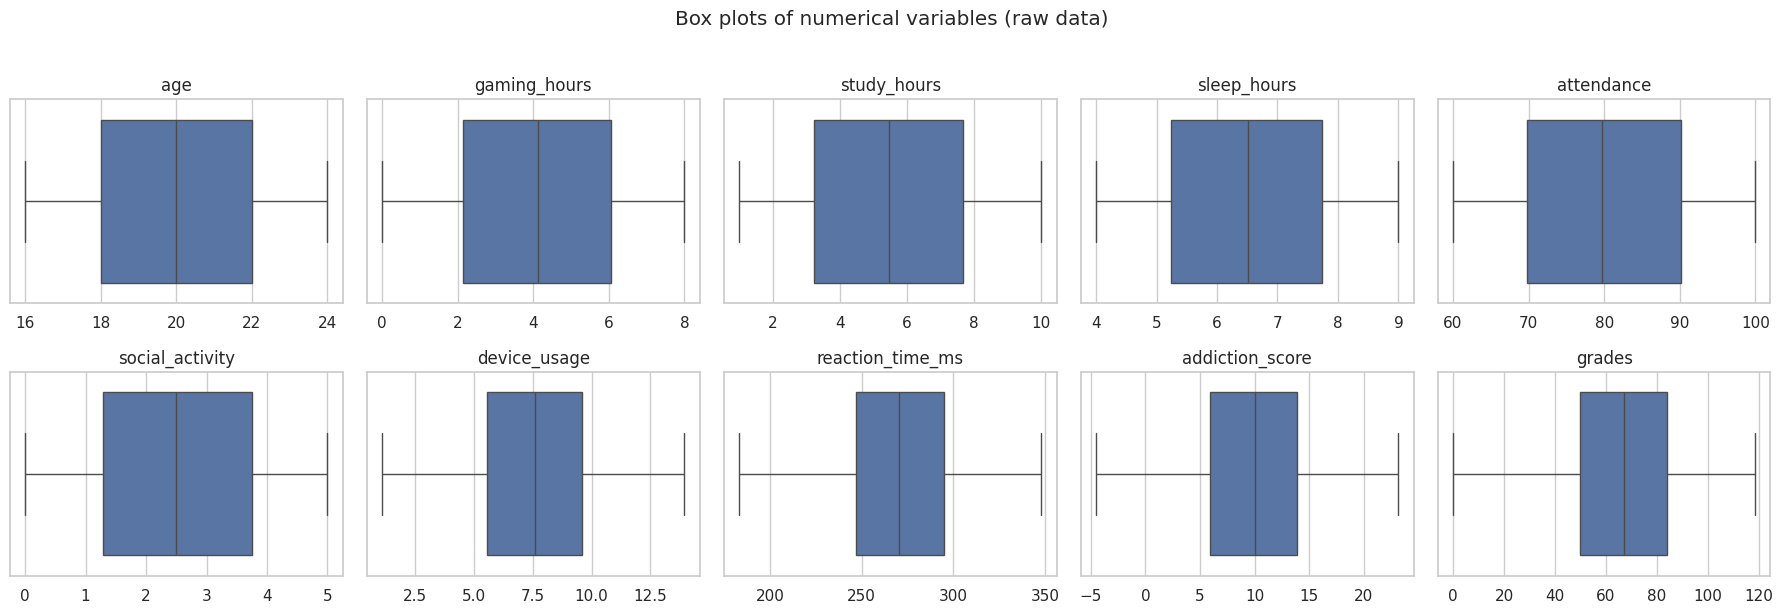

In [13]:
cols = num_cols + [target]
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flat, cols):
    sns.boxplot(x=data[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Box plots of numerical variables (raw data)', y=1.02)
plt.tight_layout()
plt.show()

**Conclusion:** Using the IQR rule, **no variable has statistical outliers** (0 points outside the whiskers). However, *no outliers* does not mean *no errors*: the invalid values found in 2.4 lie inside the whiskers and can only be found with domain rules.

## 2.7. Cleaning decisions log

In [14]:
df = data.copy()                                   # cleaned copy - raw data stays untouched
df['grades'] = df['grades'].clip(0, 100)
df['addiction_score'] = df['addiction_score'].clip(lower=0)
df['stress_level_num'] = df['stress_level'].map({'Low': 1, 'Medium': 2, 'High': 3})

print('grades > 100 after cleaning        :', (df['grades'] > 100).sum())
print('addiction_score < 0 after cleaning :', (df['addiction_score'] < 0).sum())

df.drop(columns='stress_level_num').to_csv('Gaming_Academic_Performance_clean.csv', index=False)
print('Saved: Gaming_Academic_Performance_clean.csv')

grades > 100 after cleaning        : 0
addiction_score < 0 after cleaning : 0
Saved: Gaming_Academic_Performance_clean.csv


| Issue | Rows | % | Action |
| --- | --- | --- | --- |
| `grades` > 100 | 134 | 1.7% | clipped to 100 |
| `addiction_score` < 0 | 107 | 1.3% | clipped to 0 |
| `grades` with many decimals | 1,671 | 20.9% | kept, noted as a limitation |
| gaming + study + sleep > 24 h | 98 | 1.2% | kept, noted as a limitation |

The cleaned data is stored in `df` and saved as `Gaming_Academic_Performance_clean.csv` for the modelling notebook. **All analysis below uses `df`.**

> **Vì sao "clip" thay vì xóa dòng?** Số dòng lỗi ít (< 2%) và các cột khác của những dòng này vẫn hợp lệ. Xóa dòng làm mất thông tin; clip chỉ sửa đúng giá trị sai. Clip theo ngưỡng cố định (0, 100) không dùng thông tin từ dữ liệu nên **không gây data leakage** khi làm trước bước chia train/test.

# 3. Univariate Analysis

## 3.1. Target variable

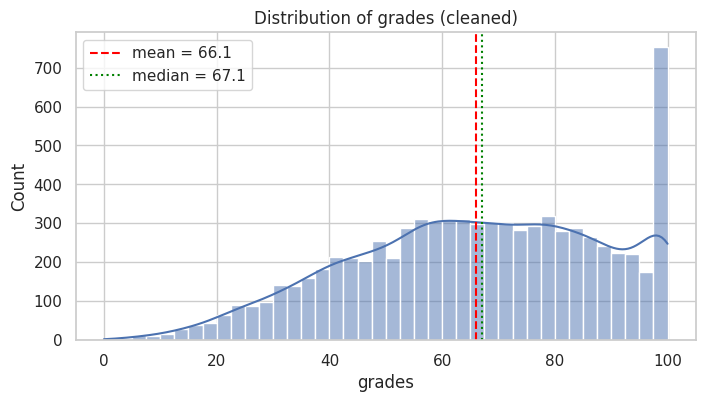

skew: -0.283 | grades == 100: 573


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df[target], bins=40, kde=True, ax=ax)
ax.axvline(df[target].mean(), color='red', ls='--', label=f'mean = {df[target].mean():.1f}')
ax.axvline(df[target].median(), color='green', ls=':', label=f'median = {df[target].median():.1f}')
ax.set_title('Distribution of grades (cleaned)')
ax.legend()
plt.show()

print('skew:', round(df[target].skew(), 3), '| grades == 100:', (df[target] == 100).sum())

**Conclusion:** Grades range from 0 to 100, with a mean of **66.1** and a median of **67.1**. The distribution is **slightly left-skewed** (skew = -0.28) with a long tail towards low grades. After cleaning, **573 students (7.2%) have exactly 100**, a clear ceiling effect. Because grades are not normally distributed, **non-parametric methods** (Spearman, Kruskal-Wallis) are used below. For modelling, the ceiling means a linear model may predict values above 100.

## 3.2. Numerical features

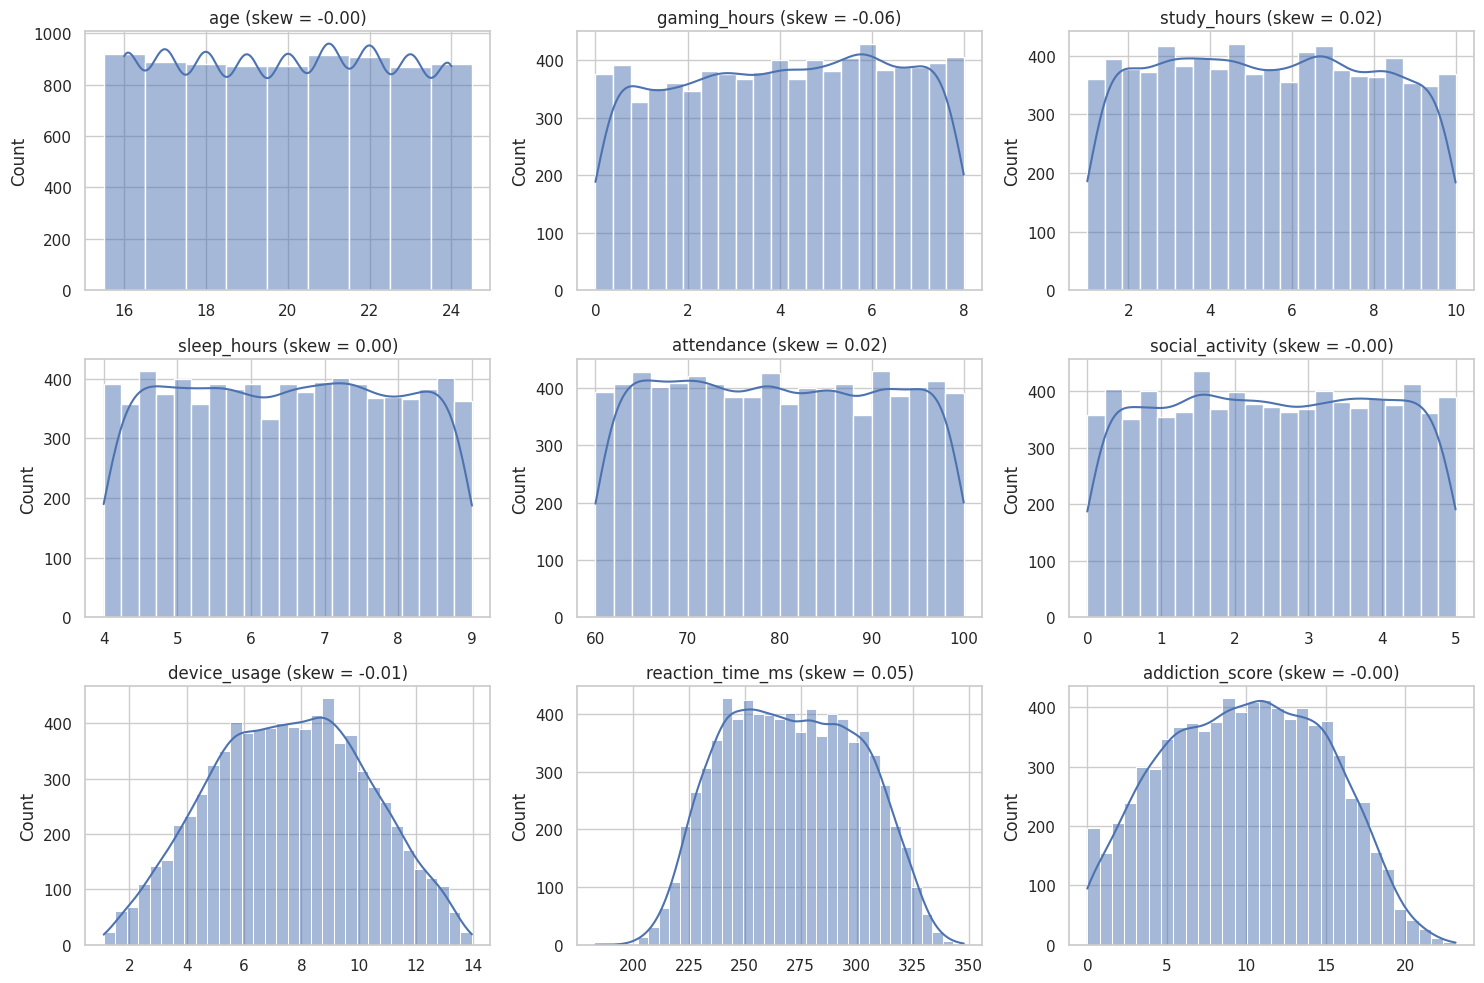

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, discrete=(col == 'age'), ax=ax)
    ax.set_title(f'{col} (skew = {df[col].skew():.2f})')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Conclusion:**
- All numerical features are **approximately symmetric** (|skew| < 0.1), so no log transformation is needed.
- **Uniform (flat) distributions:** `age`, `gaming_hours`, `study_hours`, `sleep_hours`, `attendance` and `social_activity`. Real behavioural data rarely looks like this, which supports the idea that the data is synthetic.
- **Bell-shaped / trapezoid distributions:** `device_usage`, `reaction_time_ms` and `addiction_score`. This shape appears when a uniform variable is combined with random noise, which suggests these three are **derived from another variable** (checked in 4.3).

## 3.3. Categorical features

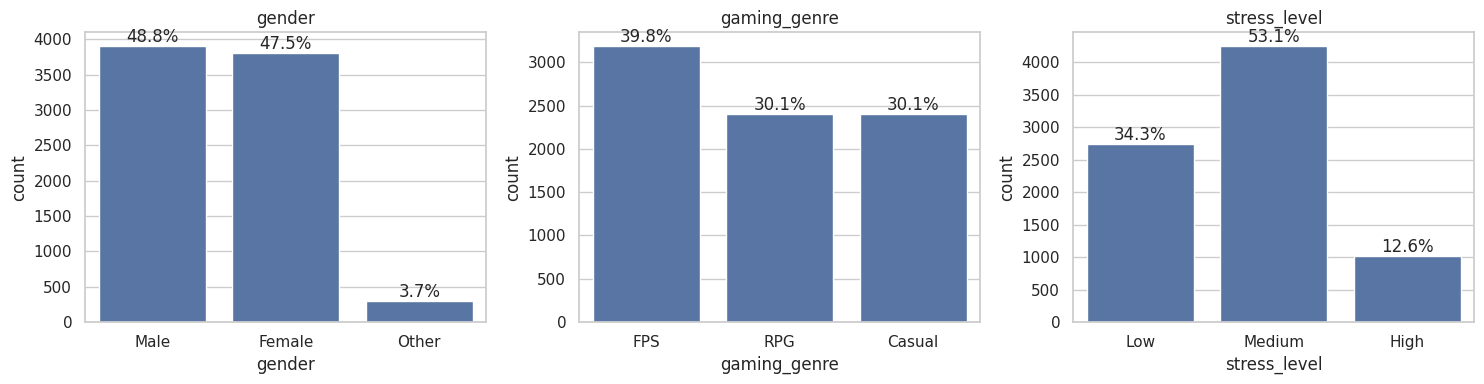

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols + ord_cols):
    order = stress_order if col == 'stress_level' else df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    pct = df[col].value_counts(normalize=True).reindex(order) * 100
    ax.bar_label(ax.containers[0], labels=[f'{p:.1f}%' for p in pct])
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Conclusion:**
- **Gender:** Male (48.8%) and Female (47.5%) are balanced. **Other is small (3.7%, about 300 students)**, so results for this group are less reliable.
- **Gaming genre:** FPS is the most common (39.8%); Casual and RPG are equal (30.1% each).
- **Stress level:** Medium 53.1%, Low 34.3%, High 12.6%, so the classes are **imbalanced**.

# 4. Bivariate Analysis

## 4.1. Numerical features vs target

In [18]:
corr_cols = num_cols + ['stress_level_num']
corr_table = pd.DataFrame({
    'pearson' : df[corr_cols].corrwith(df[target], method='pearson'),
    'spearman': df[corr_cols].corrwith(df[target], method='spearman'),
}).round(3)
corr_table.sort_values('spearman', key=abs, ascending=False)

,pearson,spearman
study_hours,0.733,0.741
gaming_hours,-0.552,-0.541
reaction_time_ms,0.518,0.510
stress_level_num,0.499,0.498
addiction_score,-0.497,-0.492
device_usage,-0.469,-0.465
sleep_hours,0.249,0.243
attendance,0.130,0.126
social_activity,-0.019,-0.017
age,0.008,0.010


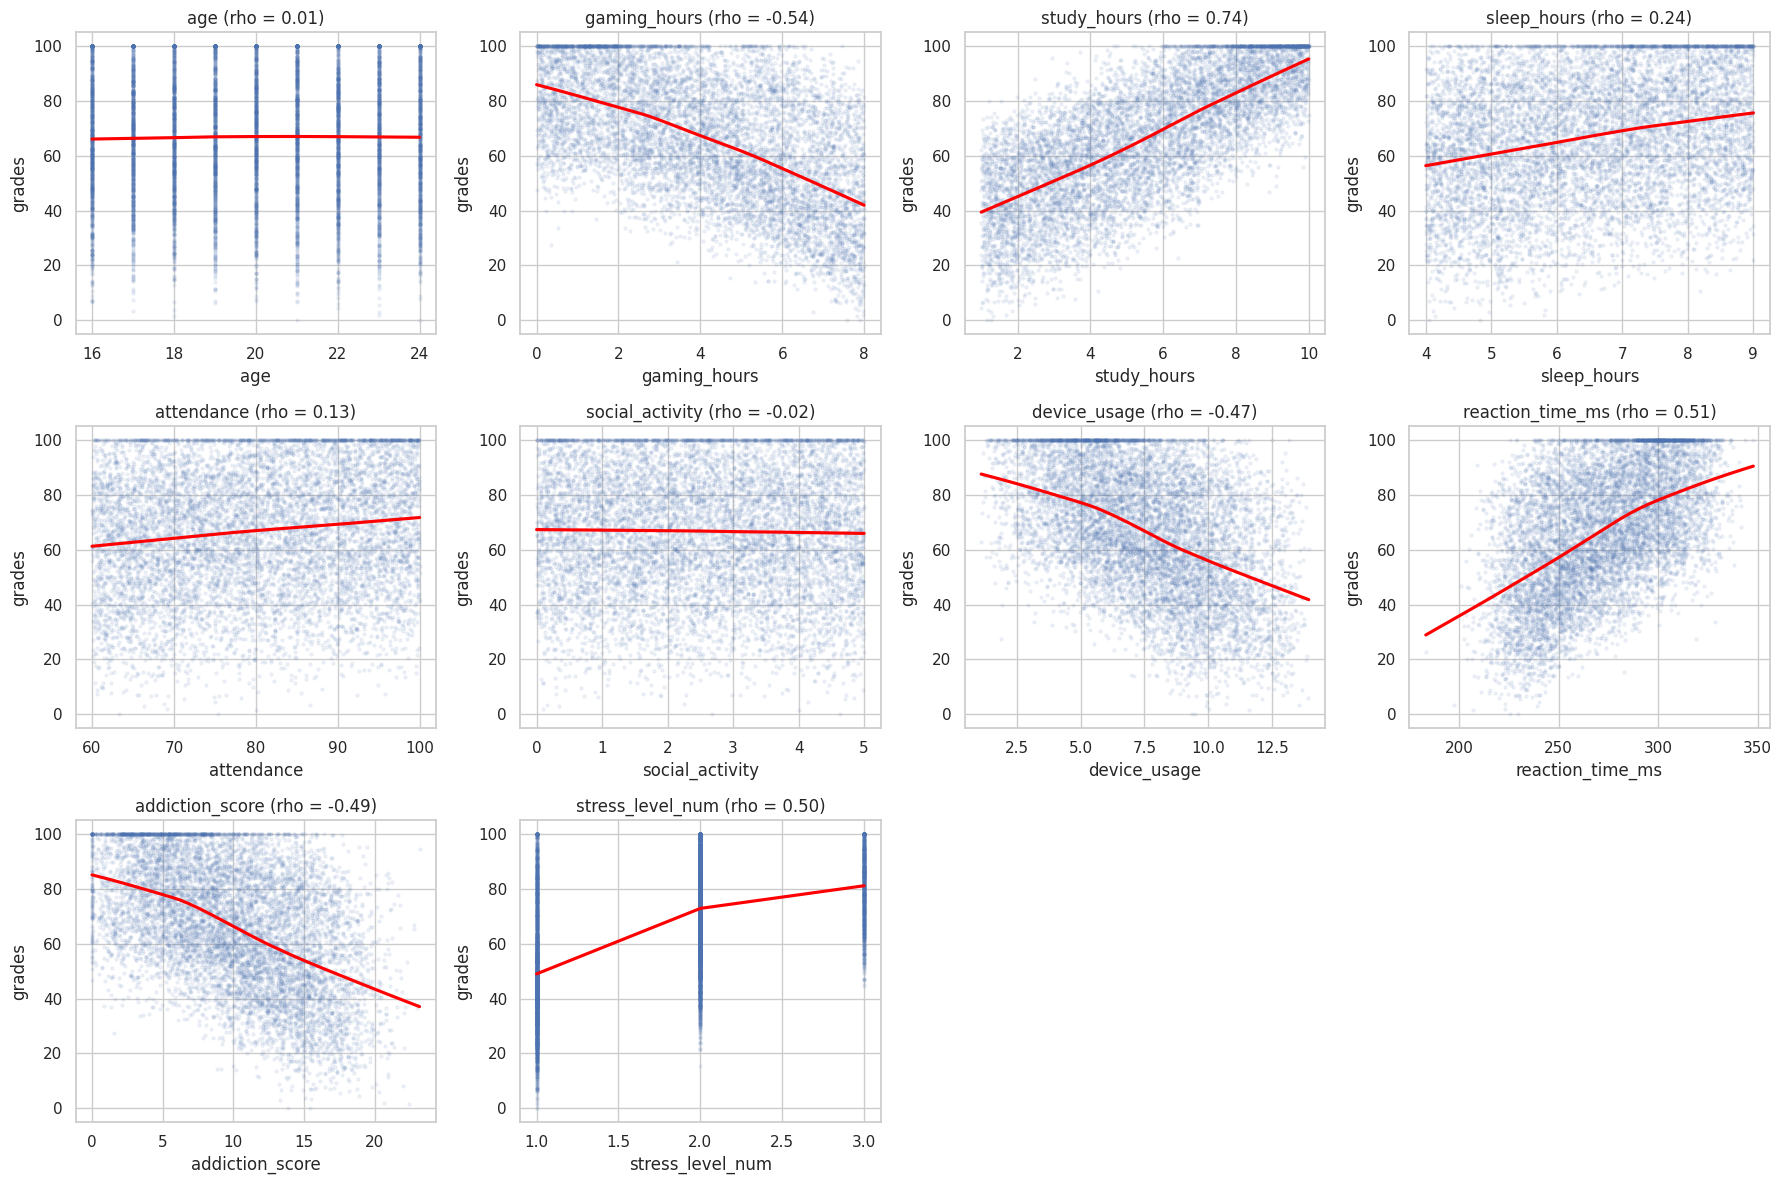

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, col in zip(axes.flat, corr_cols):
    sns.regplot(data=df, x=col, y=target, lowess=True, ax=ax,
                scatter_kws={'alpha': 0.08, 's': 5}, line_kws={'color': 'red'})
    ax.set_title(f'{col} (rho = {corr_table.loc[col, "spearman"]:.2f})')
for ax in axes.flat[len(corr_cols):]:
    ax.set_visible(False)            # hide empty subplots
plt.tight_layout()
plt.show()

**Conclusion:**
- **`study_hours` has the strongest relationship with grades** (ρ = 0.74): students who study more tend to get higher grades.
- **Moderate negative:** `gaming_hours` (-0.54), `addiction_score` (-0.49) and `device_usage` (-0.47).
- **Weak positive:** `sleep_hours` (0.24) and `attendance` (0.13).
- **No relationship:** `age` and `social_activity` (|ρ| < 0.02).
- **Two counter-intuitive results:** `reaction_time_ms` (+0.51, slower reaction linked to higher grades) and `stress_level_num` (+0.50, higher stress linked to higher grades). These are investigated in 4.3 and 5.3.
- Pearson and Spearman are almost identical, and the LOWESS lines are close to straight, so the relationships are **approximately linear**.

## 4.2. Categorical features vs target

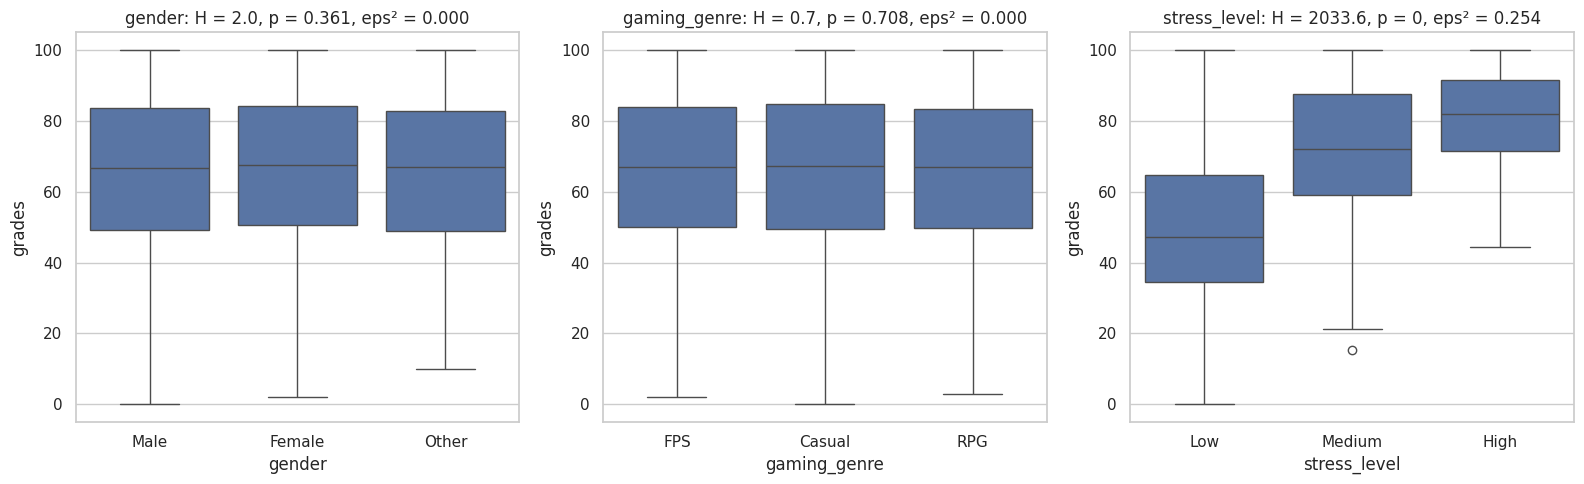

gender {'Female': 67.6, 'Male': 66.6, 'Other': 67.0}
gaming_genre {'Casual': 67.3, 'FPS': 66.9, 'RPG': 67.0}
stress_level {'High': 82.0, 'Low': 47.4, 'Medium': 72.1}


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols + ord_cols):
    order = stress_order if col == 'stress_level' else None
    sns.boxplot(data=df, x=col, y=target, order=order, ax=ax)
    h, p = stats.kruskal(*[g[target] for _, g in df.groupby(col)])
    eps2 = h / (len(df) - 1)                        # effect size for Kruskal-Wallis
    ax.set_title(f'{col}: H = {h:.1f}, p = {p:.3g}, eps² = {eps2:.3f}')
plt.tight_layout()
plt.show()

for col in cat_cols + ord_cols:
    print(col, df.groupby(col)[target].median().round(1).to_dict())

**Conclusion (Kruskal-Wallis test):**
- **Gender** (p = 0.36) and **gaming genre** (p = 0.71): no significant difference; median grades are about 67 in every group. *What* students play does not matter.
- **Stress level** (H = 2034, p < 0.001, ε² = 0.25, a large effect): median grades are **47.4 (Low), 72.1 (Medium) and 82.0 (High)**. The highest-stress group has the highest grades, which is explained in 5.3.

## 4.3. Feature vs feature (hypothesis-driven)

**Hypotheses:**
- H1: Heavy gamers react faster, which would explain why reaction time is *positively* linked to grades.
- H2: `addiction_score` and `device_usage` mostly measure the same thing as `gaming_hours`.
- H3: Gaming reduces grades because it takes time away from study or sleep.

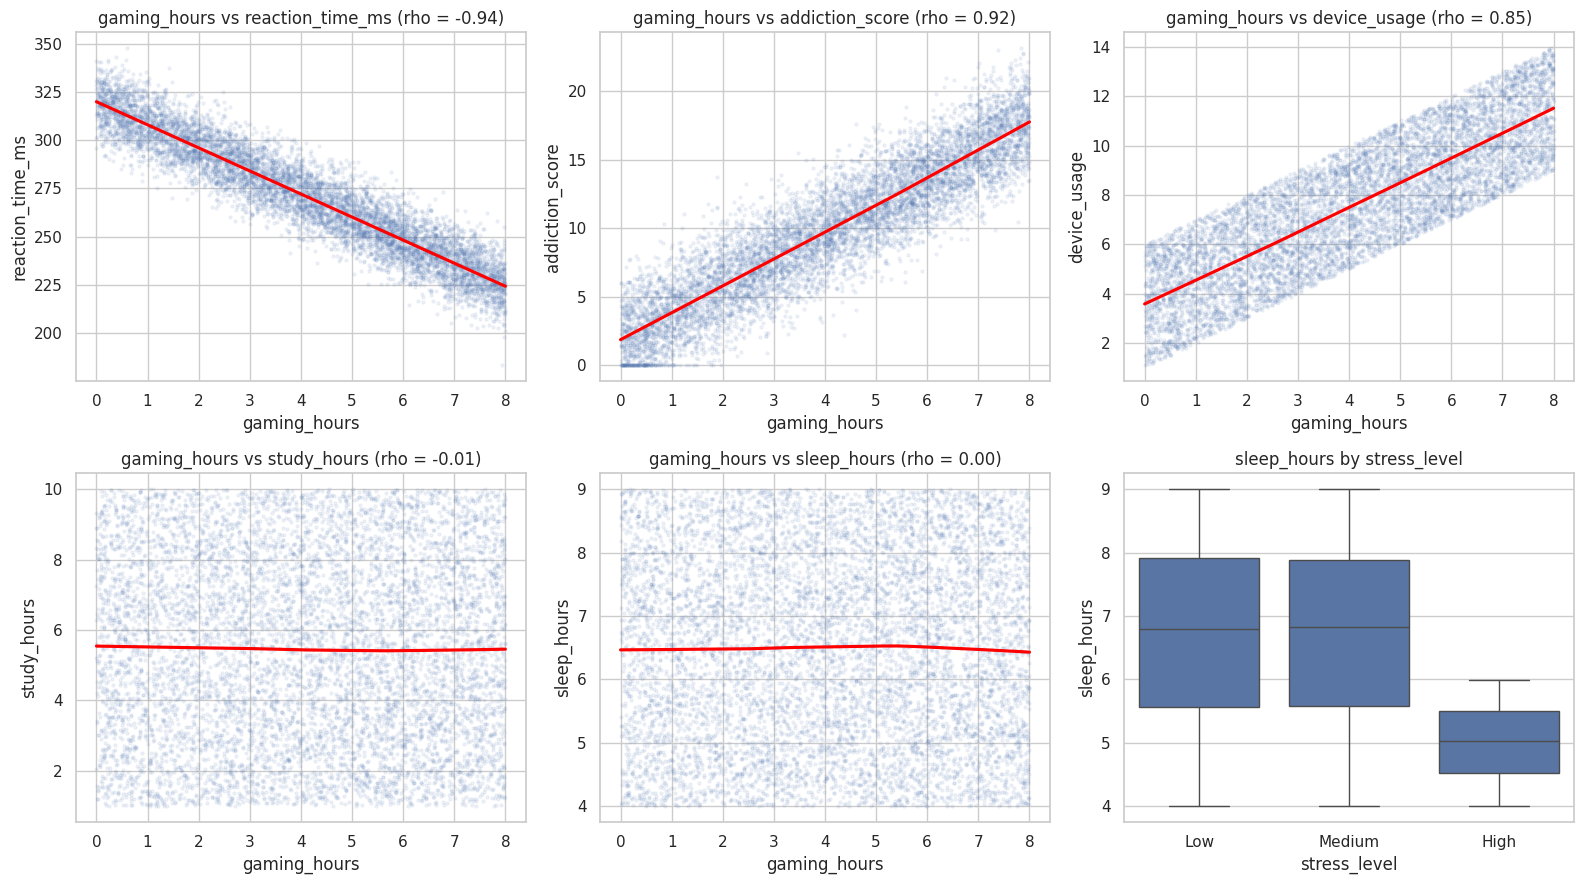

In [21]:
pairs = [('gaming_hours', 'reaction_time_ms'), ('gaming_hours', 'addiction_score'),
         ('gaming_hours', 'device_usage'), ('gaming_hours', 'study_hours'),
         ('gaming_hours', 'sleep_hours')]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (x, y) in zip(axes.flat, pairs):
    sns.regplot(data=df, x=x, y=y, lowess=True, ax=ax,
                scatter_kws={'alpha': 0.08, 's': 5}, line_kws={'color': 'red'})
    ax.set_title(f'{x} vs {y} (rho = {df[x].corr(df[y], method="spearman"):.2f})')
sns.boxplot(data=df, x='stress_level', y='sleep_hours', order=stress_order, ax=axes[1, 2])
axes[1, 2].set_title('sleep_hours by stress_level')
plt.tight_layout()
plt.show()

**Conclusion:**
- **H1 supported:** `gaming_hours` and `reaction_time_ms` are almost perfectly related (ρ = -0.94). Heavy gamers react faster *and* get lower grades, so reaction time is only a **proxy of gaming hours**, not a cause of better grades.
- **H2 supported:** `addiction_score` (ρ = 0.92) and `device_usage` (ρ = 0.85) are also strongly driven by gaming hours.
- **H3 rejected:** gaming hours are **not related** to study hours (ρ = -0.01) or sleep hours (ρ = 0.00). In this data, gaming does not take time away from study or sleep; its negative link with grades is a **separate, direct effect**.
- High-stress students all sleep **less than 6 hours** (see 5.3).

# 5. Multivariate Analysis

## 5.1. Correlation matrix

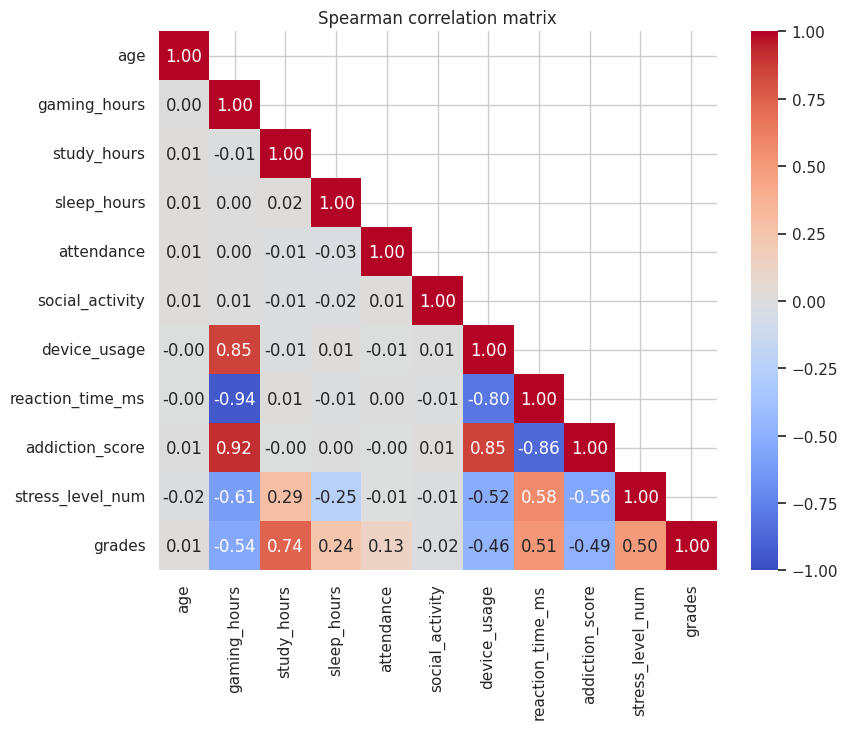

In [22]:
corr = df[corr_cols + [target]].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)     # show lower triangle only
plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Spearman correlation matrix')
plt.show()

**Conclusion:** There is one clear **"gaming cluster"**: `gaming_hours`, `device_usage`, `reaction_time_ms` and `addiction_score` are strongly correlated with each other (|ρ| = 0.80–0.94) and carry mostly the **same information**. All other features are almost uncorrelated with each other (|ρ| ≈ 0), except `stress_level_num`, which is related to gaming (-0.61), study (0.29) and sleep (-0.25).

## 5.2. Multicollinearity (VIF)

In [23]:
X = add_constant(df[corr_cols])                          # features only - no target
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
                index=X.columns).drop('const').sort_values(ascending=False).round(2)
vif.to_frame('VIF')

,VIF
gaming_hours,15.210
reaction_time_ms,8.510
addiction_score,6.620
device_usage,4.040
stress_level_num,1.940
study_hours,1.200
sleep_hours,1.160
attendance,1.000
social_activity,1.000
age,1.000


**Conclusion:** `gaming_hours` has a **VIF of about 15 (> 10, serious multicollinearity)**, followed by `reaction_time_ms` (≈ 8.5) and `addiction_score` (≈ 6.5). All other features have VIF < 5. For a linear model, keep only `gaming_hours` from the gaming cluster, or use regularisation (Ridge/Lasso).

## 5.3. Confounding & interaction

In [24]:
df.groupby('stress_level')[['study_hours', 'sleep_hours', 'gaming_hours', target]] \
  .agg(['min', 'max', 'mean']).reindex(stress_order).round(2)

study_hours              sleep_hours             gaming_hours  \
                     min    max  mean         min   max  mean          min   
stress_level                                                                 
Low                1.000 10.000 4.990       4.000 9.000 6.710        5.010   
Medium             1.000 10.000 5.050       4.000 9.000 6.700        0.000   
High               7.010 10.000 8.450       4.000 5.990 5.020        0.000   

                         grades                 
               max  mean    min     max   mean  
stress_level                                    
Low          8.000 6.490  0.000 100.000 50.500  
Medium       5.000 2.540 15.460 100.000 72.620  
High         7.990 4.060 44.410 100.000 80.890

In [25]:
# Hypothesis from the table: stress_level is created by a simple rule
rule = np.where((df['sleep_hours'] < 6) & (df['study_hours'] > 7), 'High',
       np.where(df['gaming_hours'] > 5, 'Low', 'Medium'))
print(f"Rule matches stress_level for {(rule == df['stress_level']).mean():.1%} of students")

Rule matches stress_level for 100.0% of students


**Conclusion (confounding):** `stress_level` is **not an independent measurement**. It follows a fixed rule (100% match):
- **High** = sleeps less than 6 hours **and** studies more than 7 hours
- **Low** = games more than 5 hours (and is not High)
- **Medium** = everyone else

So "high stress → high grades" does **not** mean stress improves grades. High-stress students are the ones who **study a lot**, and "low-stress" students are **heavy gamers**. `study_hours` and `gaming_hours` are **confounders**. In a model, `stress_level` adds little new information and could cause **data leakage** in a real setting.

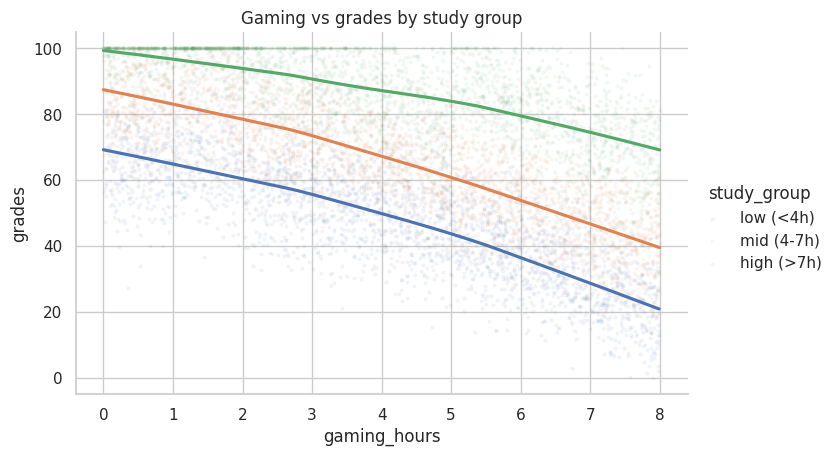

,coef,p_value
Intercept,15.522,0.000
study_hours,4.705,0.000
gaming_hours,-7.343,0.000
study_hours:gaming_hours,0.381,0.000
sleep_hours,3.724,0.000
attendance,0.278,0.000


In [26]:
# Interaction: does the effect of gaming depend on how much a student studies?
df['study_group'] = pd.cut(df['study_hours'], [0, 4, 7, 10], labels=['low (<4h)', 'mid (4-7h)', 'high (>7h)'])
sns.lmplot(data=df, x='gaming_hours', y=target, hue='study_group', lowess=True,
           scatter_kws={'alpha': 0.05, 's': 4}, height=4.5, aspect=1.6)
plt.title('Gaming vs grades by study group')
plt.show()

inter = smf.ols('grades ~ study_hours * gaming_hours + sleep_hours + attendance', data=df).fit()
inter.params.round(3).to_frame('coef').join(inter.pvalues.round(4).rename('p_value'))

**Conclusion (interaction):** The interaction term `study_hours:gaming_hours` is positive and significant (coef ≈ 0.38, p < 0.001): gaming seems to hurt **slightly less** for students who study more. However, this may be partly caused by the **ceiling at 100**: students who study a lot are already close to 100, so their grades cannot rise much when they game less. A tree-based model can capture this kind of non-linear pattern automatically.

## 5.4. Multivariable check (baseline model)

In [27]:
full = smf.ols('grades ~ study_hours + gaming_hours + sleep_hours + attendance + social_activity'
               ' + device_usage + reaction_time_ms + addiction_score + age + C(gender) + C(gaming_genre)',
               data=df).fit()
small = smf.ols('grades ~ study_hours + gaming_hours + sleep_hours + attendance', data=df).fit()

print(f'R² full model (all features, no stress): {full.rsquared:.3f}')
print(f'R² small model (4 features)            : {small.rsquared:.3f}')
pd.DataFrame({'coef': full.params, 'p_value': full.pvalues}).round(4)

R² full model (all features, no stress): 0.911
R² small model (4 features)            : 0.911


,coef,p_value
Intercept,8.108,0.001
C(gender)[T.Male],-0.020,0.895
C(gender)[T.Other],-0.279,0.490
C(gaming_genre)[T.FPS],0.112,0.532
C(gaming_genre)[T.RPG],0.050,0.796
study_hours,6.253,0.000
gaming_hours,-5.322,0.000
sleep_hours,3.728,0.000
attendance,0.276,0.000
social_activity,-0.042,0.412


**Conclusion:** When all features are in the model together, only **4 are significant (p < 0.05)**: `study_hours` (+6.3 points per hour), `gaming_hours` (-5.3 per hour), `sleep_hours` (+3.7 per hour) and `attendance` (+0.28 per 1%). The gaming proxies, demographics and genre become non-significant. The **4-feature model explains 91% of the variance** (R² = 0.911), the same as the full model.

# 6. Summary & Next Steps

## 6.1. Key findings

1. **Data quality (Q1):** the data is complete, with no duplicates and no statistical outliers. A small number of invalid values (1–2%) were fixed by clipping.
2. **Study hours** is the strongest driver of grades (ρ = 0.74, +6.3 points per extra hour when other factors are held constant).
3. **Gaming hours** is the main negative driver (ρ = -0.54, -5.3 points per hour). Gaming does **not** reduce study or sleep time in this data. Its effect is direct.
4. **Sleep** (+3.7 per hour) and **attendance** (+0.28 per %) have smaller but real positive effects.
5. **Game genre and gender do not matter (Q3)** (p > 0.3). Only the *amount* of gaming matters.
6. **Redundant features (Q4):** `device_usage`, `reaction_time_ms` and `addiction_score` are proxies of gaming hours (|ρ| ≥ 0.85, high VIF). `stress_level` is generated from study, sleep and gaming by a fixed rule.
7. **Best features for prediction (Q5):** `study_hours`, `gaming_hours`, `sleep_hours` and `attendance` explain **91%** of the variance.

## 6.2. Data quality issues

134 grades above 100 and 107 negative addiction scores were clipped to valid ranges. Grades are capped at 100 (7.2% of students). 1,671 grades have unusual decimals, and 98 students report more than 24 daily hours. These were kept and noted.

## 6.3. Limitations

- The data is very likely **synthetic** (uniform distributions, near-zero correlations, rule-based stress level), so the findings should **not** be generalised to real students.
- This is observational data: the results show **associations, not causation**.
- The "Other" gender group is small (3.7%), so results for this group are less reliable.
- The ceiling at 100 limits what linear models can learn at the top of the grade range.

## 6.4. Recommendations for modelling

- Use the cleaned file `Gaming_Academic_Performance_clean.csv`.
- **Do not use `stress_level`** as a feature (it is derived from other features, which risks leakage) and drop `student_id`.
- Baseline: **Linear Regression** with the 4 key features. Compare it with **Ridge/Lasso** on all features, and with **tree-based models** (Random Forest, Gradient Boosting) to capture the ceiling and the interaction.
- Evaluate with a train/test split and cross-validation, using MAE, RMSE and R².

→ See **`Modelling.ipynb`**.